# Week 5 — calibrated discrete covariate HMMs on DTU CO2 data

**Scope.** One room, 30-minute aggregation, **discrete** models only: a Gaussian and an
autoregressive emission with a covariate-driven (`DynamicTransition`) transition, plus a
**second-order** covariate transition (`DynamicTransitionHigherOrder`) that asks whether the
chain's memory buys anything once the covariates are already in the transition.

**Calibration.** The NDIR sensors drift, so the floor of a room's CO2 series sits wherever the
sensor's zero happens to be rather than at the ~400 ppm outdoor background. Before fitting we
shift the whole series by one constant so its minimum is exactly 400 ppm. A pure shift leaves
every difference, gap and dynamic untouched — it only makes the level comparable across rooms
and physically interpretable.

**Evaluation.** Rolling **6-hour-ahead** forecasts against a persistence baseline
(RMSE / MAPE / R2), residual diagnostics, and in-sample LL / AIC / BIC.

## Imports and config

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # must come before anything touches JAX

from pathlib import Path

import pandas as pd
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from src.api.v4 import (
    HMM, GaussEmission, AutoregressiveGaussEmission,
    DynamicTransition, DynamicTransitionHigherOrder, ForwardAlgorithm, AIC, BIC,
)
from src.base.utils import transition_matrix_to_logits
from drivers.utils import plot_hmm_diagnostics

In [2]:
room_name     = "Room 009"
STATES        = 3
AR_LAGS       = 1
ORDER         = 2          # Markov order of the higher-order transition
TEST_SIZE     = 0.2
BIN           = "30min"
BIN_SECONDS   = 1800
HORIZON_HOURS = 6
BASELINE_PPM  = 400.0


weather_cols = [
    "mean_temp", 
    "mean_relative_hum", 
    "mean_wind_speed",
    "mean_pressure", 
    "mean_cloud_cover", 
    "mean_radiation",
]

SERIES_PATH = "data/raw/dtu/timeseries"

## Calibration

`calibrate_baseline` is the whole calibration: a single offset chosen so that
`min(ys) -> baseline`. Spread, differences and autocorrelation are unchanged.

In [3]:
def calibrate_baseline(ys: jnp.ndarray, baseline: float = BASELINE_PPM) -> jnp.ndarray:
    """Shift a CO2 series so its minimum sits at `baseline` ppm (sensor-floor correction).

    A constant offset: every difference in the series is preserved, only the level moves.
    """
    ys = jnp.asarray(ys, dtype=float)
    return ys - jnp.min(ys) + baseline

## Load and clean the raw series

Drop NaN CO2, the 4000+ ppm sensor-saturation ceiling, and exact duplicate `(datetime, co2)`
readings.

In [4]:
series_df = pd.read_csv(Path(SERIES_PATH) / f"{room_name}.csv")
series_df = series_df.dropna(subset=["co2"]).copy()
series_df["datetime"] = pd.to_datetime(series_df["datetime"])

non_saturated = series_df[(series_df["co2"] <= 4000) & series_df["co2"].notna()]
df_raw = (
    non_saturated.drop_duplicates(subset=["datetime", "co2"])
    .sort_values("datetime")
    .reset_index(drop=True)[["datetime", "co2"]]
)
print(f"{room_name}: {len(df_raw)} cleaned raw observations")
print(f"  from {df_raw['datetime'].iloc[0]} to {df_raw['datetime'].iloc[-1]}")

Room 009: 14346 cleaned raw observations
  from 2023-11-01 00:01:53 to 2024-02-09 13:05:40


## Covariate builder

`build_covariates(datetimes)` returns an `(N, D)` matrix of an off-day flag, cyclical week /
time-of-day encodings, and hourly weather matched by time. Same builder as `week_4_agg.ipynb`.

In [5]:
# --- Holidays -----------------------------------------------------------
try:
    import holidays as _holidays
    _dk_holidays = _holidays.Denmark()

    def _is_holiday(d):
        return d.date() in _dk_holidays
except ImportError:
    _DK_HOLIDAYS = {
        pd.Timestamp("2024-01-01"), pd.Timestamp("2024-03-28"), pd.Timestamp("2024-03-29"),
        pd.Timestamp("2024-03-31"), pd.Timestamp("2024-04-01"), pd.Timestamp("2024-04-26"),
        pd.Timestamp("2024-05-09"), pd.Timestamp("2024-05-19"), pd.Timestamp("2024-05-20"),
        pd.Timestamp("2024-12-25"), pd.Timestamp("2024-12-26"),
    }

    def _is_holiday(d):
        return d.normalize() in _DK_HOLIDAYS

# --- Weather ------------------------------------------------------------

weather_df = pd.read_csv("data/raw/dtu/weather.csv", parse_dates=["DateFrom", "DateTo"])
weather_df = (
    weather_df[["DateFrom", *weather_cols]].dropna().sort_values("DateFrom").reset_index(drop=True)
)


def _weather_features(datetimes):
    """Match hourly weather (UTC) to each local, tz-naive observation time."""
    local = pd.DatetimeIndex(datetimes).tz_localize(
        "Europe/Copenhagen", ambiguous="NaT", nonexistent="shift_forward"
    )
    left = pd.DataFrame({"t": local.tz_convert("UTC")})
    left["order"] = np.arange(len(left))
    left = left.sort_values("t")
    merged = pd.merge_asof(
        left, weather_df.rename(columns={"DateFrom": "t"}), on="t", direction="nearest",
    )
    merged = merged.sort_values("order")
    return merged[weather_cols].ffill().bfill().to_numpy()


def build_covariates(datetimes):
    """Return an (N, D) covariate matrix for a series of pandas datetimes."""
    dt = pd.DatetimeIndex(datetimes)
    is_weekend = dt.dayofweek >= 5
    is_holiday = np.array([_is_holiday(d) for d in dt])
    off_day = (is_weekend | is_holiday).astype(float)

    seconds_into_week = dt.dayofweek * 86400 + dt.hour * 3600 + dt.minute * 60 + dt.second
    week_angle = 2 * np.pi * seconds_into_week / (7 * 86400)
    sin_week, cos_week = np.sin(week_angle), np.cos(week_angle)

    seconds_into_day = dt.hour * 3600 + dt.minute * 60 + dt.second
    tod_angle = 2 * np.pi * seconds_into_day / 86400
    sin_tod, cos_tod = np.sin(tod_angle), np.cos(tod_angle)

    calendar = np.column_stack([off_day, sin_week, cos_week, sin_tod, cos_tod])
    weather = _weather_features(datetimes)
    return np.column_stack([calendar, weather])

covariate_cols = ["off_day", "sin_week", "cos_week", "sin_tod", "cos_tod", *weather_cols]

## Aggregate to 30-min bins and keep the longest gap-free run

Resample CO2 to a regular 30-min grid (mean of the raw readings in each bin). A bin with no
reading is a >30 min gap, which splits the grid into contiguous segments where neighbours are
exactly 30 min apart. We keep the **longest** segment, so the discrete models see a genuinely
regular time index.

In [6]:
co2_binned = df_raw.set_index("datetime")["co2"].resample(BIN).mean()

filled = co2_binned.notna().values
seg_id = np.cumsum(~filled)                      # increments at every empty (NaN) bin
segments = [co2_binned[filled & (seg_id == s)] for s in np.unique(seg_id[filled])]
seg = max(segments, key=len)

START, END = seg.index[0], seg.index[-1]
print(f"{len(segments)} gap-free 30-min segments; longest = {len(seg)} bins")
print(f"Selected window: {START} -> {END}  ({(END - START).total_seconds()/3600:.1f} h)")

ys_uncal  = jnp.asarray(seg.values)              # as recorded by the sensor
dates_agg = pd.DatetimeIndex(seg.index)
X_agg     = jnp.asarray(build_covariates(dates_agg))

2 gap-free 30-min segments; longest = 4244 bins
Selected window: 2023-11-13 03:30:00 -> 2024-02-09 13:00:00  (2121.5 h)


### Apply the calibration

offset applied: +33.33 ppm
                   min       max      mean       std
uncalibrated    366.67   3654.00    899.10    535.43
calibrated      400.00   3687.33    932.44    535.43


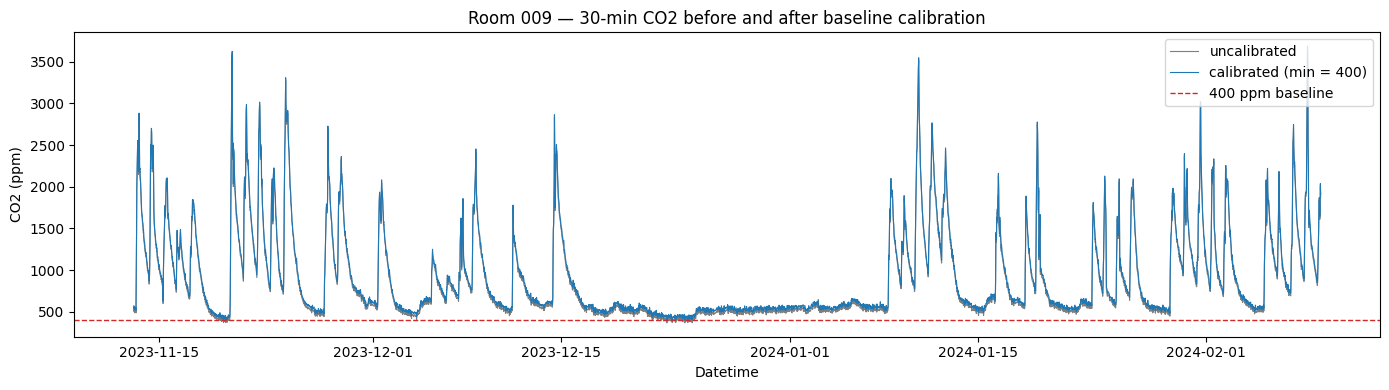

In [7]:
ys_agg = calibrate_baseline(ys_uncal)            # everything downstream uses the calibrated series
offset = float(jnp.min(ys_uncal) - BASELINE_PPM)

print(f"offset applied: {-offset:+.2f} ppm")
print(f"{'':<12}{'min':>10}{'max':>10}{'mean':>10}{'std':>10}")
for label, arr in (("uncalibrated", ys_uncal), ("calibrated", ys_agg)):
    print(f"{label:<12}{float(jnp.min(arr)):10.2f}{float(jnp.max(arr)):10.2f}"
          f"{float(jnp.mean(arr)):10.2f}{float(jnp.std(arr)):10.2f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_agg, np.asarray(ys_uncal), lw=0.8, color="tab:gray", label="uncalibrated")
ax.plot(dates_agg, np.asarray(ys_agg), lw=0.8, color="tab:blue", label="calibrated (min = 400)")
ax.axhline(BASELINE_PPM, color="tab:red", ls="--", lw=1.0, label=f"{BASELINE_PPM:.0f} ppm baseline")
ax.set_title(f"{room_name} — 30-min CO2 before and after baseline calibration")
ax.set_ylabel("CO2 (ppm)")
ax.set_xlabel("Datetime")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Train/test split

One split boundary in wall-clock time. Covariates are z-scored with **training** statistics only,
so nothing from the test period leaks into the scaling.

In [8]:
def standardise(X, train_mask):
    mean = X[train_mask].mean(axis=0)
    std  = jnp.where(X[train_mask].std(axis=0) == 0, 1.0, X[train_mask].std(axis=0))
    return (X - mean) / std


TRAIN_IDX  = int(len(ys_agg) * (1 - TEST_SIZE))
SPLIT_TIME = dates_agg[TRAIN_IDX]
train_mask = np.arange(len(ys_agg)) < TRAIN_IDX

ys_train    = ys_agg[:TRAIN_IDX]
X_std       = standardise(X_agg, train_mask)
X_train_std = X_std[:TRAIN_IDX]

num_covariates = X_agg.shape[1]
# A DynamicTransition has no time-invariant matrix, so the stationary distribution is
# undefined — pass an explicit (uniform) initial distribution instead.
init_dist = jnp.full(STATES, 1.0 / STATES)

print(f"Split time: {SPLIT_TIME}")
print(f"Train/test bins: {TRAIN_IDX}/{len(ys_agg) - TRAIN_IDX}")
print(f"Covariates: {num_covariates} ({', '.join(covariate_cols)})")

Split time: 2024-01-22 21:00:00
Train/test bins: 3395/849
Covariates: 11 (off_day, sin_week, cos_week, sin_tod, cos_tod, mean_temp, mean_relative_hum, mean_wind_speed, mean_pressure, mean_cloud_cover, mean_radiation)


## Fit the two discrete covariate HMMs

Both use `DynamicTransition` (covariate-driven) with `ts=None`, i.e. unit 30-min steps. Seeds come
from the calibrated training series, so the monotone mean construction
`mu0 + cumsum(exp(log_mu_diff))` starts in the right range. The autoregressive model is
warm-started from the fitted Gaussian model (emission means/sigmas and transition), with the AR
coefficients at zero — at `phi = 0` it *is* the Gaussian model, so the fit can only improve on it.

In [9]:
def state_means(emission, ys):
    """Per-state base means, whichever emission is asked.

    `GaussEmission` exposes them directly as `mu`; the autoregressive emission splits
    them into `mu_vals` (state base) and `mu` (base + AR term on the previous value).
    """
    return getattr(emission, "mu_vals", emission.mu)(0, ys)


mu_seed    = jnp.quantile(ys_train, jnp.linspace(0.05, 0.95, STATES))
sigma_seed = jnp.std(ys_train) * jnp.ones(STATES)
tm_seed    = jnp.full((STATES, STATES), 0.1).at[jnp.diag_indices(STATES)].set(0.7)
beta_init  = jnp.zeros((num_covariates, STATES, STATES - 1))

print("=== Gaussian HMM + covariates (30-min, calibrated) ===")
gauss_cov = HMM(
    emission=GaussEmission.from_params(mu_seed, sigma_seed),
    transition=DynamicTransition(transition_matrix_to_logits(tm_seed), beta_init),
    inital_distribution=init_dist,
)
gauss_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2)
print("  log-likelihood:", gauss_cov.log_likelihood())
print("  converged:", gauss_cov.hmm_results.convergence)

=== Gaussian HMM + covariates (30-min, calibrated) ===
  log-likelihood: -21337.635887083896
  converged: True


In [10]:
print("=== Autoregressive HMM + covariates (30-min, calibrated) ===")
mu_warm    = state_means(gauss_cov.emission, ys_train)          # fitted state means
sigma_warm = jnp.exp(gauss_cov.emission.log_sigma)

ar_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(
        mu_warm, sigma_warm, jnp.zeros((AR_LAGS, STATES))
    ),
    transition=DynamicTransition(
        gauss_cov.transition.transition_logits, gauss_cov.transition.beta
    ),
    inital_distribution=init_dist,
)
ar_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2)
print("  log-likelihood:", ar_cov.log_likelihood())
print("  converged:", ar_cov.hmm_results.convergence)
print("  phi (per state):", np.asarray(ar_cov.emission.phi()))

=== Autoregressive HMM + covariates (30-min, calibrated) ===
  log-likelihood: -16675.648861198883
  converged: True
  phi (per state): [[0.79242039 0.95116669 0.86698459]]


## Fit a second-order covariate HMM

The chain now runs on **augmented states** `(s_{t-1}, s_t)` — `STATES**ORDER = 16` of them — with
`DynamicTransitionHigherOrder`: covariate-driven like `DynamicTransition`, order-`ORDER` like
`StaticTransitionHigherOrder`. Structurally impossible moves (those whose history does not line up)
are pinned to zero probability, so each augmented state still has only `STATES` real successors.

Two things keep the comparison honest:

- **Tied covariate effects.** `beta` stays `(D, STATES, STATES-1)`, broadcast to every augmented row
  sharing the same current base state. The covariate budget is identical to the first-order model, so
  the only thing added is memory.
- **An exact warm start.** `DynamicTransitionHigherOrder.from_first_order(ar_cov.transition)` lifts
  the fitted first-order transition onto the augmented space, re-referencing the logits so the
  lifted chain reproduces the first-order one at *every* covariate value. The fit therefore starts
  at the first-order optimum.

The emission is autoregressive again, with the `STATES` base means tiled up to the 16 augmented
states (`mu_vals` already does that), so the mean depends only on the current base state.


In [11]:
print("=== Second-order HMM + covariates (30-min, calibrated) ===")
AUG_STATES = STATES ** ORDER

# Augmented state i encodes (s_{t-1}, s_t) as i = s_{t-1} * STATES + s_t, so the current
# base state is i % STATES. `mu_vals` tiles the STATES base means up to len(log_sigma),
# so sigma and phi must be *tiled* (not repeated) to stay aligned with that convention.
mu_so    = state_means(ar_cov.emission, ys_train)[:STATES]         # base means, (STATES,)
sigma_so = jnp.tile(jnp.exp(ar_cov.emission.log_sigma), STATES)    # (AUG_STATES,)
phi_so   = jnp.tile(ar_cov.emission.phi(), (1, STATES))            # (AR_LAGS, AUG_STATES)

so_cov = HMM(
    emission=AutoregressiveGaussEmission.from_params(mu_so, sigma_so, phi_so),
    transition=DynamicTransitionHigherOrder.from_first_order(ar_cov.transition, order=ORDER),
    # No stationary distribution for a covariate-driven chain — uniform over the 16
    # augmented states, whose base-state marginal is the uniform used by the other models.
    inital_distribution=jnp.full(AUG_STATES, 1.0 / AUG_STATES),
)

# Check the lift before spending a fit on it: at the seed this model *is* the fitted
# AR + covariate model, so the two log-likelihoods must agree.
ll_seed = so_cov.log_likelihood(ys=ys_train, xs=X_train_std)
ll_ar   = ar_cov.log_likelihood(ys=ys_train, xs=X_train_std)
print(f"  seed LL {ll_seed:.4f} vs AR+cov LL {ll_ar:.4f}  (difference {ll_seed - ll_ar:.2e})")

so_cov.fit(ys=ys_train, ts=None, xs=X_train_std, tol=1e-2)
print("  log-likelihood:", so_cov.log_likelihood())
print("  converged:", so_cov.hmm_results.convergence)
print("  transition params:", so_cov.transition.transition_logits.size,
      "baseline logits +", so_cov.transition.beta.size, "beta")

# Only the means stay tied to the STATES base states — the fit gets one sigma per
# augmented state, and an almost-never-visited state lets its sigma run toward 0
# (the usual unbounded-likelihood spike). Show occupancy and sigma side by side so
# that is visible rather than buried in the log-likelihood.
utt_so = np.asarray(so_cov.state_results.utt).reshape(len(ys_train), -1)
print("\n  mean filtered occupancy (rows = s_{t-1}, cols = s_t):")
print(np.round(utt_so.mean(axis=0).reshape(-1, STATES), 4))
print("  fitted sigmas (same layout):")
print(np.round(np.asarray(jnp.exp(so_cov.emission.log_sigma)).reshape(-1, STATES), 3))


=== Second-order HMM + covariates (30-min, calibrated) ===
  seed LL -16675.6489 vs AR+cov LL -16675.6489  (difference 0.00e+00)
  log-likelihood: -16636.702984122647
  converged: True
  transition params: 18 baseline logits + 66 beta

  mean filtered occupancy (rows = s_{t-1}, cols = s_t):
[[1.032e-01 6.200e-03 5.000e-04]
 [5.700e-03 7.668e-01 7.700e-03]
 [0.000e+00 8.900e-03 1.008e-01]]
  fitted sigmas (same layout):
[[ 21.399   8.221 107.441]
 [ 16.29   25.258 117.447]
 [ 21.345  79.312 215.567]]


In [12]:
models = {"Gaussian + cov": gauss_cov,
          "Autoregressive + cov": ar_cov,
          "Second-order + cov": so_cov}

for name, m in models.items():
    # Means stay tied to the STATES base states (`mu_vals` tiles them), so one period
    # of them is the whole story. Sigmas are not tied: the second-order model fits one
    # per augmented state, so print the full grid for it.
    mu = np.asarray(state_means(m.emission, ys_train))
    sd = np.asarray(jnp.exp(m.emission.log_sigma))
    print(f"{name}")
    print(f"  state means : {np.round(mu[:STATES], 1)}")
    if sd.size == STATES:
        print(f"  state sigmas: {np.round(sd, 1)}")
    else:
        print(f"  state sigmas (rows = s_t-1, cols = s_t):")
        print(np.round(sd.reshape(-1, STATES), 2))


Gaussian + cov
  state means : [ 473.6  571.3 1320. ]
  state sigmas: [ 34.2  42.2 549.1]
Autoregressive + cov
  state means : [ 471.1  576.3 2346.1]
  state sigmas: [ 21.3  25.3 208.6]
Second-order + cov
  state means : [ 475.5  583.9 2378.6]
  state sigmas (rows = s_t-1, cols = s_t):
[[ 21.4    8.22 107.44]
 [ 16.29  25.26 117.45]
 [ 21.34  79.31 215.57]]


## In-sample fit criteria

In [13]:
rows = []
for name, m in models.items():
    res = m.hmm_results
    rows.append({
        "Model": name,
        "LL": res.log_likelihood,
        "#Params": res.num_params,
        "AIC": AIC(res),
        "BIC": BIC(res, len(ys_train)),
        "Converged": res.convergence,
    })

fit_table = pd.DataFrame(rows)
fit_table["dAIC"] = fit_table["AIC"] - fit_table["AIC"].min()
fit_table["dBIC"] = fit_table["BIC"] - fit_table["BIC"].min()
fit_table = fit_table[["Model", "LL", "#Params", "AIC", "dAIC", "BIC", "dBIC", "Converged"]]
fit_table.round(2)

,Model,LL,#Params,AIC,dAIC,BIC,dBIC,Converged
0,Gaussian + cov,-21337.64,78,42831.27,9347.87,43309.42,9299.58,True
1,Autoregressive + cov,-16675.65,81,33513.30,29.89,34009.83,0.00,True
2,Second-order + cov,-16636.70,105,33483.41,0.00,34127.06,117.23,True


## Residual diagnostics

`plot_hmm_diagnostics` (from `drivers/utils.py`) shows the log-likelihood per solver iteration,
a normal Q-Q plot of the forecast pseudo-residuals, and their ACF. Under a well-specified model
the pseudo-residuals are i.i.d. standard normal, so the Q-Q line should be straight and the ACF
flat.

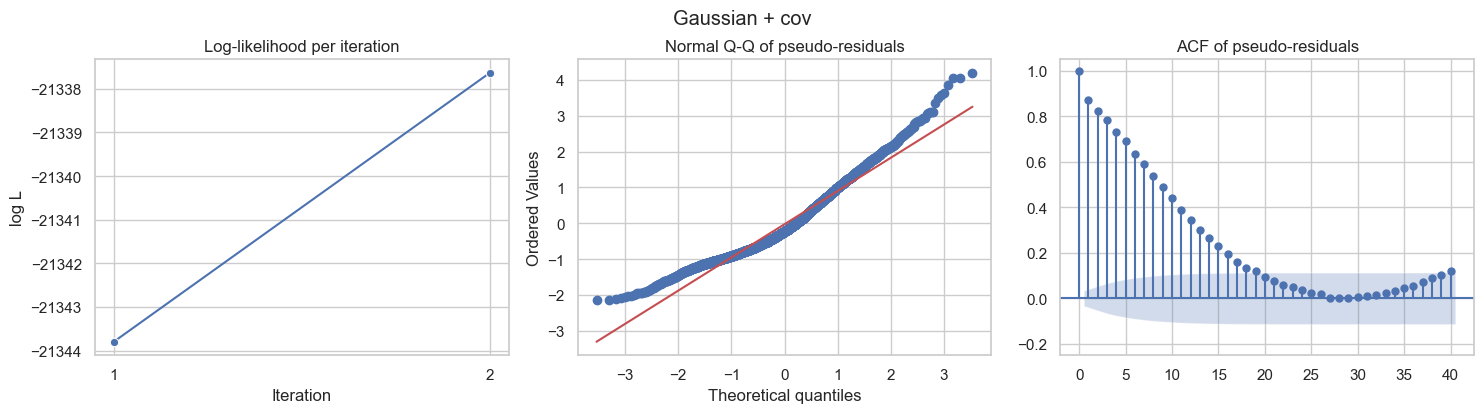

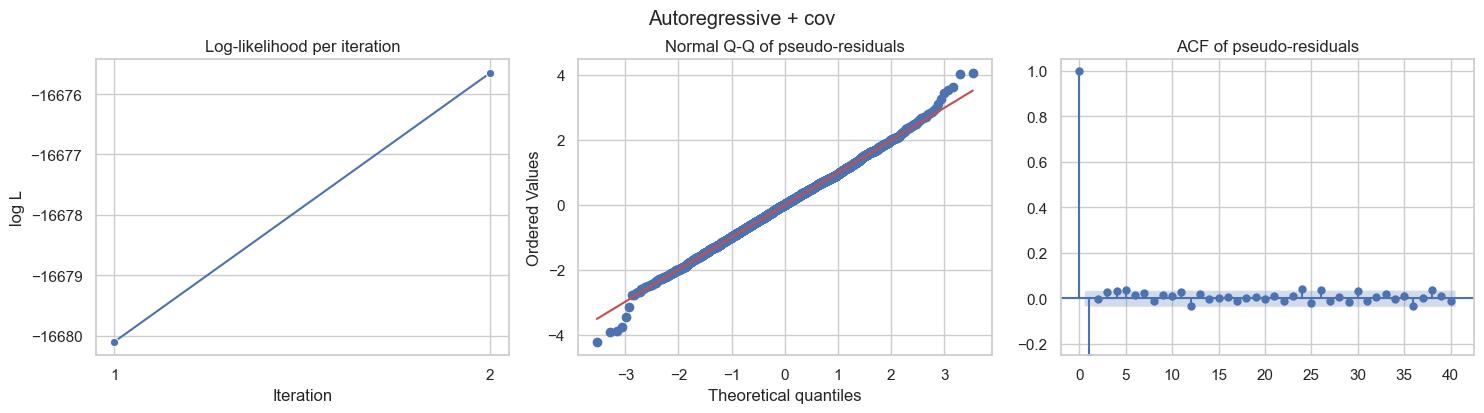

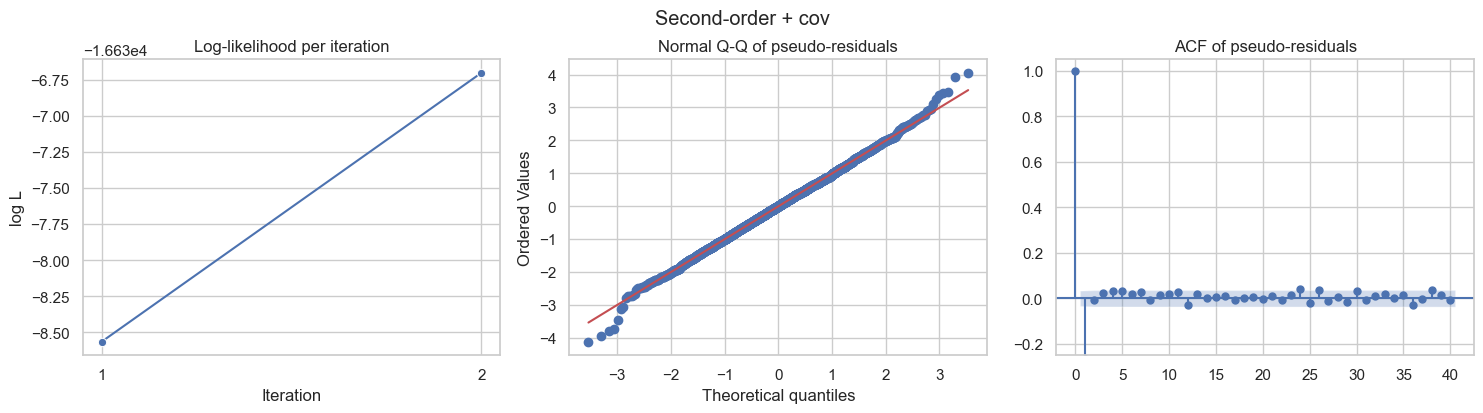

In [14]:
for name, m in models.items():
    fig = plot_hmm_diagnostics(m)
    fig.suptitle(name, y=1.03)
    plt.show()

### Decoded states over the training window

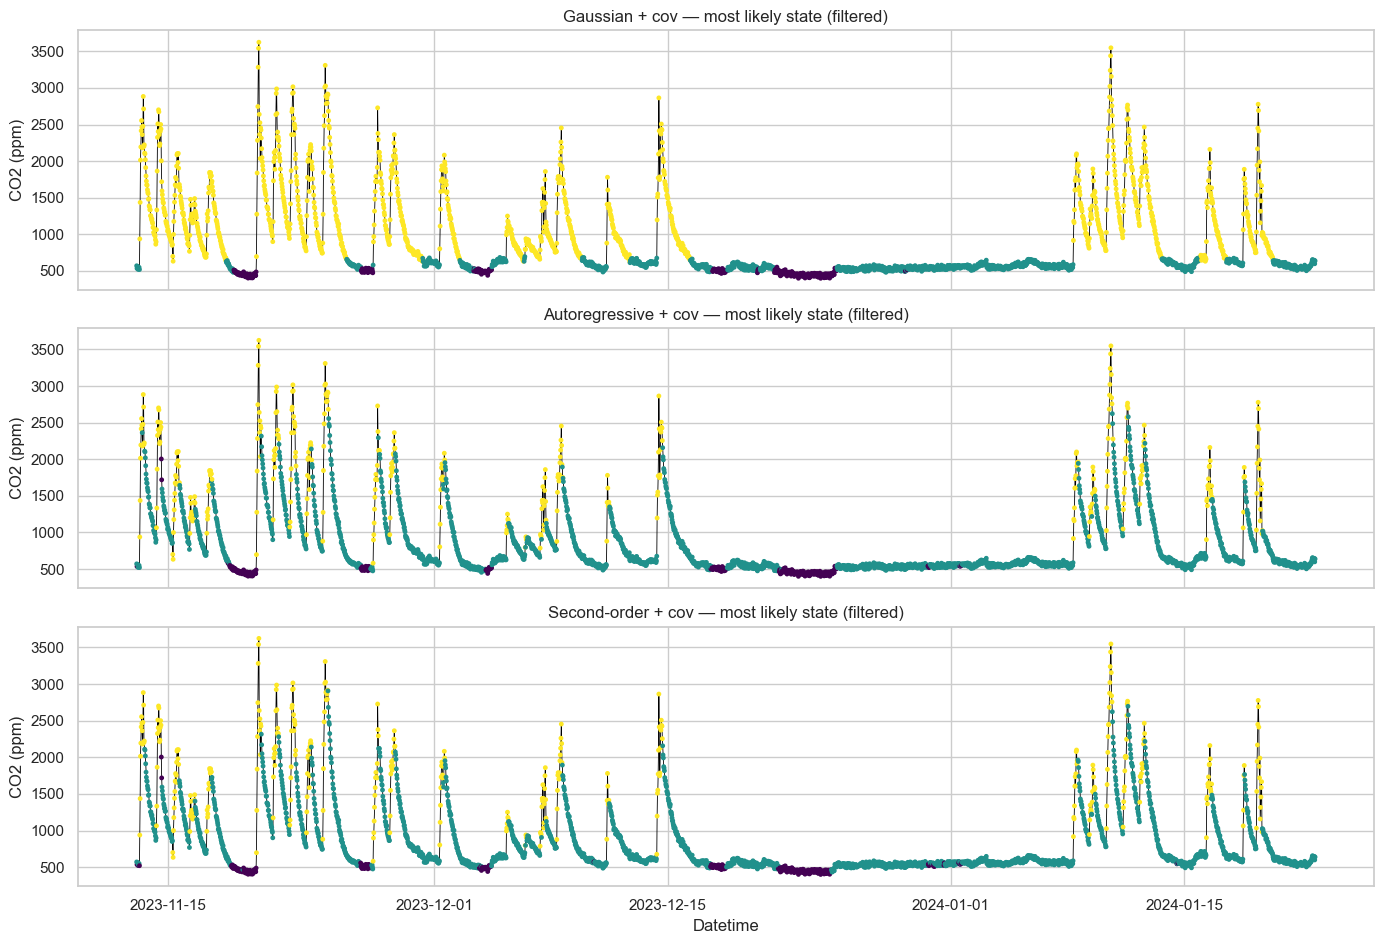

In [15]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 3.2 * len(models)), sharex=True)
for ax, (name, m) in zip(np.atleast_1d(axes), models.items()):
    utt = np.asarray(m.state_results.utt).reshape(len(ys_train), -1)
    # Augmented index i has current base state i % STATES, so the second-order
    # model shares one colour scale with the first-order ones.
    decoded = utt.argmax(axis=1) % STATES
    ax.plot(dates_agg[:TRAIN_IDX], np.asarray(ys_train), color="black", lw=0.6, zorder=1)
    ax.scatter(dates_agg[:TRAIN_IDX], np.asarray(ys_train), c=decoded, cmap="viridis",
               s=6, zorder=2)
    ax.set_title(f"{name} — most likely state (filtered)")
    ax.set_ylabel("CO2 (ppm)")
np.atleast_1d(axes)[-1].set_xlabel("Datetime")
plt.tight_layout()
plt.show()

## Predictive metrics

In [16]:
def rmse(y_true, y_pred):
    return float(jnp.sqrt(jnp.mean((y_true - y_pred) ** 2)))

def r2_score(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)

def mape(y_true, y_pred):
    return float(jnp.mean(jnp.abs((y_true - y_pred) / y_true)) * 100)

## Rolling 6-hour-ahead forecast

At **every** test observation (anchor) we take the causal filtered state and propagate it `K`
steps forward through the model's own transition matrices, then compare the emission mean to the
CO2 actually realised that far ahead. Filtering is causal, so one forward pass over the whole
series leaks nothing — the covariates at future steps are exogenous time/weather features, not
the target.

- `K = 6 h / 30 min = 12` steps.
- **Autoregressive:** the emission mean depends on the previous observation, unknown in the
  future, so the model's own running prediction is fed back in as the lag (plug-in multi-step
  forecast).

In [17]:
def rolling_discrete(model, ys, xs_std, dates, train_idx, K, is_ar=False):
    """Fixed K-step-ahead forecast anchored at every test observation (30-min grid)."""
    ys = jnp.asarray(ys)
    T = len(ys)
    out = ForwardAlgorithm().run(model.params, model.u_pre, ys=ys, ts=None, xs=xs_std)
    utt = out.utt.reshape(T, -1)                                              # (T, S)
    # transition_matrices(indices, ts, ys, xs): `ts` is ignored by a discrete
    # transition, so unit waiting times are fine here.
    Gammas = model.transition.transition_matrices(
        jnp.arange(T), jnp.ones(T), ys, xs_std
    )                                                                         # (T, S, S)

    anchors = jnp.arange(train_idx, T - K)
    u = utt[anchors]
    if not is_ar:
        mu = model.emission.mu(0, ys, xs_std)                                 # (S,)
        for m in range(1, K + 1):
            u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
        y_pred = u @ mu
    else:
        base = model.emission.mu_vals(0, ys, xs_std)                          # (S,) state base means
        phi  = model.emission.phi()[0]                                        # (S,) lag-1 coeff/state
        y_lag = ys[anchors]                                                   # last observed value
        y_pred = None
        for m in range(1, K + 1):
            u = jnp.einsum("ai,aij->aj", u, Gammas[anchors + m])
            mu_state = base[None, :] + phi[None, :] * (y_lag[:, None] - base[None, :])  # (A, S)
            y_pred = jnp.sum(u * mu_state, axis=1)                            # state-weighted mean
            y_lag = y_pred                                                    # plug-in next lag
    y_true = ys[anchors + K]
    tgt_dates = dates[np.asarray(anchors) + K]
    return tgt_dates, np.asarray(y_true), np.asarray(y_pred)


def rolling_baseline(ys, dates, train_idx, K):
    """Persistence: predict y[anchor+K] as the current value y[anchor]."""
    ys = jnp.asarray(ys)
    anchors = jnp.arange(train_idx, len(ys) - K)
    return (dates[np.asarray(anchors) + K],
            np.asarray(ys[anchors + K]),      # realised 6 h later
            np.asarray(ys[anchors]))          # current observation

In [18]:
K = int(round(HORIZON_HOURS * 3600 / BIN_SECONDS))     # 12 steps at 30 min
print(f"Horizon: {HORIZON_HOURS} h = {K} steps")

results = {}
results["Persistence baseline"]  = rolling_baseline(ys_agg, dates_agg, TRAIN_IDX, K)
results["Gaussian + cov"]        = rolling_discrete(gauss_cov, ys_agg, X_std, dates_agg, TRAIN_IDX, K, is_ar=False)
results["Autoregressive + cov"]  = rolling_discrete(ar_cov,    ys_agg, X_std, dates_agg, TRAIN_IDX, K, is_ar=True)
results["Second-order + cov"]    = rolling_discrete(so_cov,    ys_agg, X_std, dates_agg, TRAIN_IDX, K, is_ar=True)

pred_table = pd.DataFrame([
    {"Model": name,
     "RMSE": rmse(jnp.asarray(yt), jnp.asarray(yp)),
     "MAPE%": mape(jnp.asarray(yt), jnp.asarray(yp)),
     "R2": r2_score(jnp.asarray(yt), jnp.asarray(yp))}
    for name, (td, yt, yp) in results.items()
])
pred_table.round(4)

Horizon: 6 h = 12 steps


,Model,RMSE,MAPE%,R2
0,Persistence baseline,615.0917,31.7112,-0.3760
1,Gaussian + cov,468.0310,28.9176,0.2033
2,Autoregressive + cov,328.1132,15.3029,0.6085
3,Second-order + cov,323.2284,15.1228,0.6200


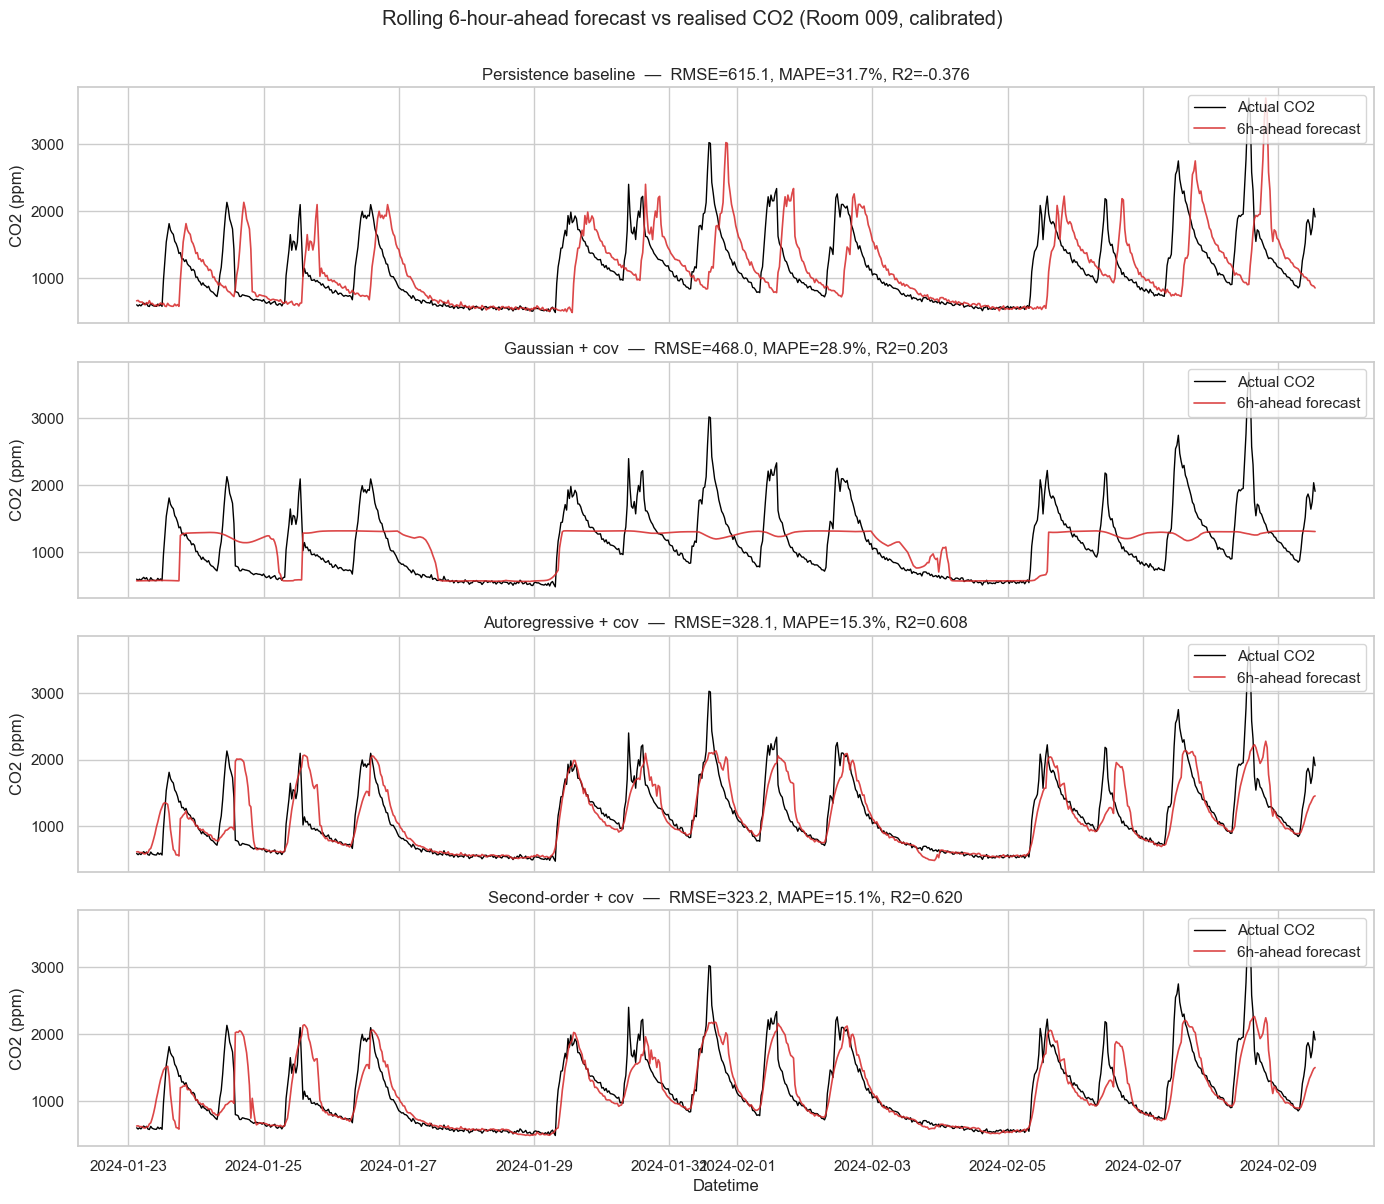

In [19]:
fig, axes = plt.subplots(len(results), 1, figsize=(14, 3 * len(results)), sharex=True)
for ax, (name, (td, yt, yp)) in zip(axes, results.items()):
    yt_j, yp_j = jnp.asarray(yt), jnp.asarray(yp)
    ax.plot(td, yt, color="black", lw=1.0, label="Actual CO2")
    ax.plot(td, yp, color="tab:red", lw=1.2, alpha=0.85, label=f"{HORIZON_HOURS}h-ahead forecast")
    ax.set_title(f"{name}  —  RMSE={rmse(yt_j, yp_j):.1f}, "
                 f"MAPE={mape(yt_j, yp_j):.1f}%, R2={r2_score(yt_j, yp_j):.3f}")
    ax.set_ylabel("CO2 (ppm)")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Datetime")
fig.suptitle(f"Rolling {HORIZON_HOURS}-hour-ahead forecast vs realised CO2 ({room_name}, calibrated)",
             y=1.002)
plt.tight_layout()
plt.show()

### Forecast errors over the test period

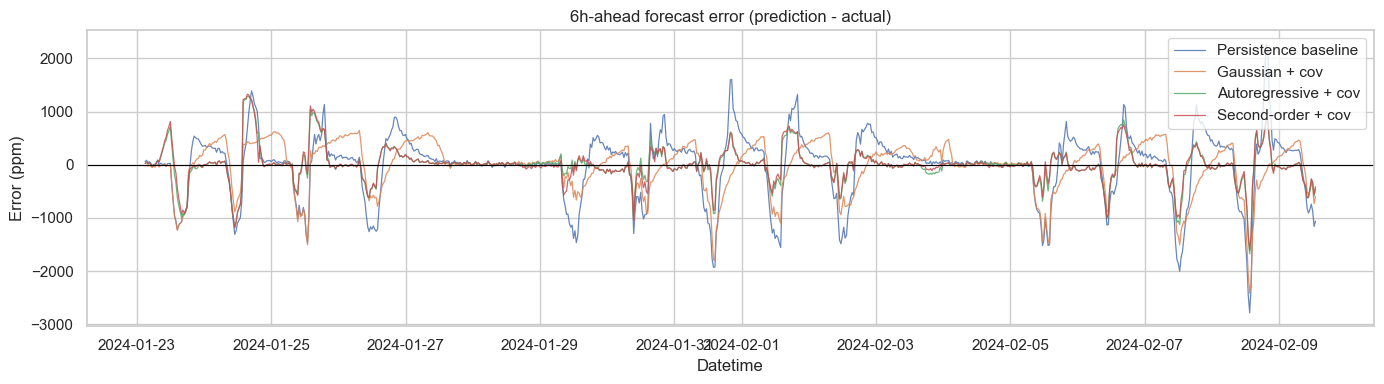

In [20]:
fig, ax = plt.subplots(figsize=(14, 4))
for name, (td, yt, yp) in results.items():
    ax.plot(td, np.asarray(yp) - np.asarray(yt), lw=0.9, alpha=0.85, label=name)
ax.axhline(0.0, color="black", lw=0.8)
ax.set_title(f"{HORIZON_HOURS}h-ahead forecast error (prediction - actual)")
ax.set_ylabel("Error (ppm)")
ax.set_xlabel("Datetime")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Notes

- Calibration is a pure level shift, so it leaves LL differences, residual diagnostics and RMSE
  untouched relative to the uncalibrated fit — what it buys is interpretable state means
  (ppm above a physical 400 ppm background) and comparability across rooms.
- Read the predictive table against the persistence baseline: at a 6 h horizon persistence is a
  genuinely hard benchmark on a series with a strong daily cycle, and beating it is what
  justifies the covariate transition.
- The AR model nests the Gaussian one at `phi = 0`, so its in-sample LL cannot be worse; whether
  the extra parameters pay off is what AIC/BIC and — more importantly — the out-of-sample
  6 h-ahead RMSE/R2 decide.
- The second-order model nests the first-order AR one too: its transition is seeded by an *exact*
  lift of the fitted `DynamicTransition` (`from_first_order`), so at the seed the two
  log-likelihoods coincide and the fit can only climb from there. What it adds is memory — the
  transition may depend on `s_{t-1}` as well as the covariates — at the cost of
  `STATES**ORDER * (STATES - 1)` baseline logits. The covariate effects are *tied over history*
  (`beta` is `(D, STATES, STATES - 1)`, indexed by the current base state), so the covariate budget
  is unchanged and the comparison isolates the memory.
- Read ΔBIC first for whether the extra baseline logits pay for themselves, but the 6 h-ahead
  RMSE/R² on the held-out period is what decides. On this room the extra memory does not clearly
  pay: it buys roughly 100 LL for 60 extra parameters, so BIC rejects it on both aggregations and
  it does not lead the held-out 6 h-ahead RMSE on either.
- Caveat on that LL: the emission **sigmas are not tied** across augmented states (only the means
  are, via `mu_vals`). The augmented states the chain almost never visits — see the occupancy grid
  printed next to each second-order fit — therefore let their sigma run toward 0, the standard
  unbounded-likelihood spike of a Gaussian mixture. Part of the LL gain is that artefact rather
  than genuine fit, which is one more reason to read the held-out RMSE and not the LL. Tying the
  sigmas to the current base state, as the means already are, is the fix worth trying next.
- A rolling 30-min mean trades induced residual autocorrelation (overlapping windows are a
  moving average, so the pseudo-residual ACF picks up short-lag structure) for twice as many
  training points and a less noisy target. Whether that trade pays off is an empirical question,
  not a free lunch.
- Only the **shared-timestamp table** compares the two aggregations fairly. Own-series RMSE
  always favours the smoothed target, and LL / AIC / BIC are not comparable across them at all.
